In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)

In [19]:
cars = pd.read_csv("prepared_car_sales.csv")

In [20]:
cars.info()
cars.describe()
cars.shape
cars.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14430 entries, 0 to 14429
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Index                    14430 non-null  int64  
 1   Price                    14430 non-null  int64  
 2   Currency                 14430 non-null  object 
 3   Condition                14430 non-null  object 
 4   Vehicle_brand            14430 non-null  object 
 5   Vehicle_model            14430 non-null  object 
 6   Vehicle_version          9887 non-null   object 
 7   Vehicle_generation       10212 non-null  object 
 8   Production_year          14430 non-null  int64  
 9   Mileage_km               14430 non-null  float64
 10  Power_HP                 14389 non-null  float64
 11  Displacement_cm3         14287 non-null  float64
 12  Fuel_type                14430 non-null  object 
 13  CO2_emissions            6536 non-null   float64
 14  Drive                 

Index(['Index', 'Price', 'Currency', 'Condition', 'Vehicle_brand',
       'Vehicle_model', 'Vehicle_version', 'Vehicle_generation',
       'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3',
       'Fuel_type', 'CO2_emissions', 'Drive', 'Transmission', 'Type',
       'Doors_number', 'Colour', 'Origin_country', 'First_owner',
       'First_registration_date', 'Offer_publication_date', 'Offer_location',
       'Features'],
      dtype='object')

array([[<Axes: title={'center': 'Index'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Production_year'}>],
       [<Axes: title={'center': 'Mileage_km'}>,
        <Axes: title={'center': 'Power_HP'}>,
        <Axes: title={'center': 'Displacement_cm3'}>],
       [<Axes: title={'center': 'CO2_emissions'}>,
        <Axes: title={'center': 'Doors_number'}>, <Axes: >]], dtype=object)

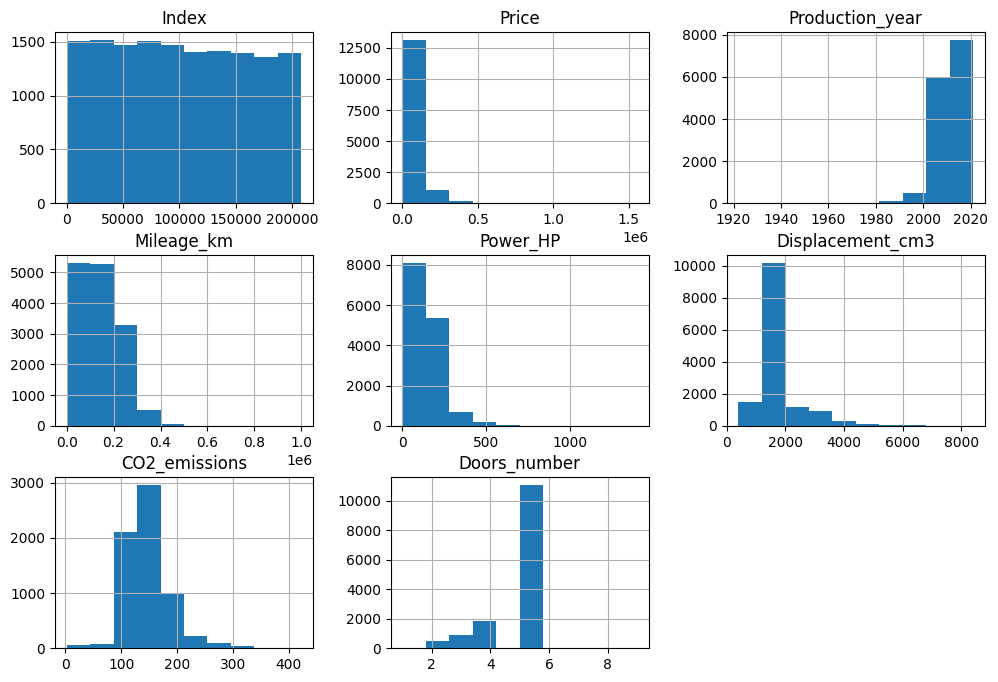

In [21]:
cars.hist(figsize=(12, 8))

In [22]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cars, test_size=0.15 , random_state=0)

In [ ]:
tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
for i, row in tmp_df.iterrows():
    if row['Currency'] == 'EUR':
        tmp_df.at[i, 'Price'] = row['Price'] * 4.26
tmp_df = tmp_df.drop(columns='Currency')
tmp_df['Condition'] = tmp_df['Condition'].map({'Used': 0, 'New': 1})
corr_mtx = tmp_df.corr()
corr_mtx['Price'].sort_values(ascending=False)

C:\Users\root\AppData\Local\Temp\ipykernel_38464\679266124.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8051.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[i, 'Price'] = row['Price'] * 4.26


Price              1.000000
Power_HP           0.628924
Condition          0.444234
Production_year    0.410088
CO2_emissions      0.188188
Mileage_km        -0.505205
Name: Price, dtype: float64

In [25]:
dummies = pd.get_dummies(train_set['Vehicle_brand'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
corrs.sort_values(ascending=False).head(10)

Porsche          0.187021
Ferrari          0.157980
McLaren          0.153468
Bentley          0.139778
Lamborghini      0.133244
BMW              0.133079
Mercedes-Benz    0.125778
Land Rover       0.118499
Rolls-Royce      0.114679
Audi             0.075250
dtype: float64

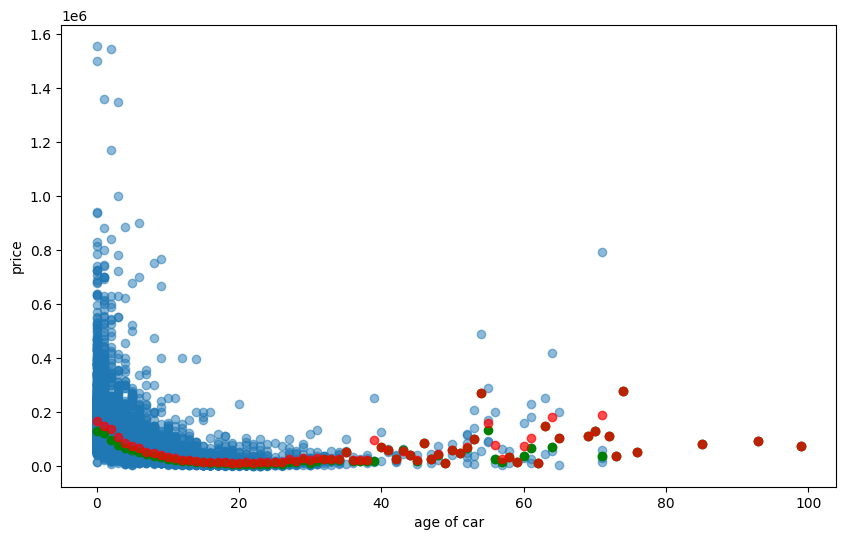

In [ ]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
avg_prices = tmp_df.groupby('Years')['Price'].mean()
median_prices = tmp_df.groupby('Years')['Price'].median()
axis.scatter(tmp_df['Years'], tmp_df['Price'], alpha=0.5)
axis.scatter(median_prices.index, median_prices, c='green', alpha=1)
axis.scatter(avg_prices.index, avg_prices, c='red', alpha=0.7)
tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='age of car')
axis.set_ylabel(ylabel='price')
plt.show()

C:\Users\root\AppData\Local\Temp\ipykernel_38464\3131783046.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\root\AppData\Local\Temp\ipykernel_38464\3131783046.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


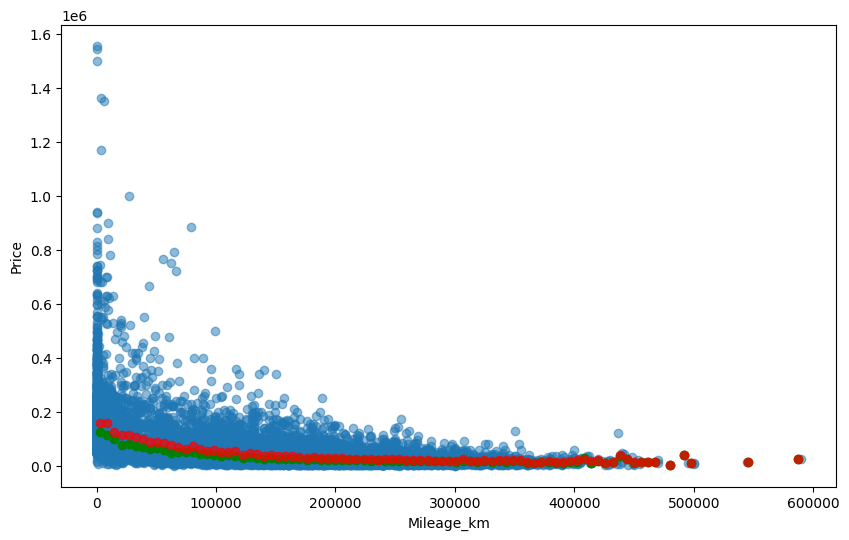

In [61]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=100)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()
# print(avg_prices)
# print(median_prices)
axis.scatter(tmp_df['Mileage_km'], tmp_df['Price'], alpha=0.5)
axis.scatter(indexes, median_prices['Price'], c='green', alpha=1)
axis.scatter(indexes, avg_prices['Price'], c='red', alpha=0.7)
# tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Price')
plt.show()